# **Random Forest Regressor  -  Insurance**

## **Importing Libraries**

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## **Loading Datasets**

In [59]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### **Creating Dummy variables to encode Categorical data**

In [60]:
df = pd.get_dummies(df, drop_first=True)
df

# Machine Learning models require numeric data – categorical features like sex or smoker need to be converted to numbers.

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


### **Split independent & dependent variable**

In [61]:
x=df.drop('charges',axis=1)
y=df['charges']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## **Random Forest Regressor**

In [62]:
model = RandomForestRegressor(random_state=42)
model.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [63]:
y_pred=model.predict(x_test)

In [64]:
print("Mean Squared error :\n",mean_squared_error(y_pred,y_test))
print("Mean Absolute Error :\n",mean_absolute_error(y_pred,y_test))
print("r2_score :\n",r2_score(y_pred,y_test))

Mean Squared error :
 20942520.922619622
Mean Absolute Error :
 2550.0784706115096
r2_score :
 0.8542327984985619


## **Random Forest - Visualization of one Tree**

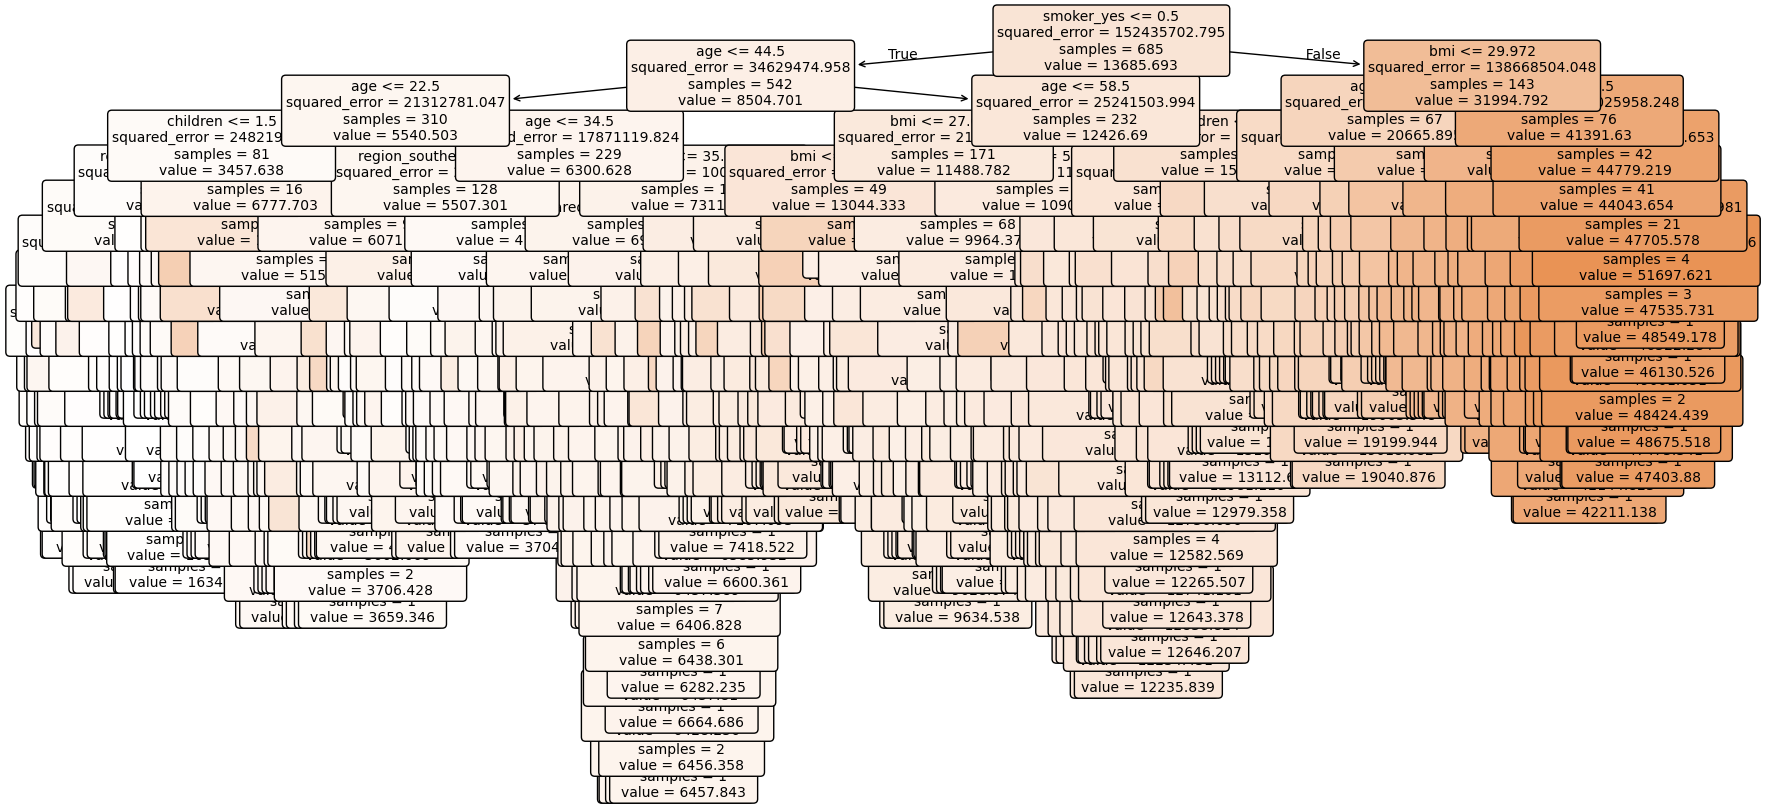

In [65]:
from sklearn.tree import export_graphviz
from sklearn import tree
import matplotlib.pyplot as plt

# Visualize the first tree in the forest
plt.figure(figsize=(20,10))
tree.plot_tree(rf.estimators_[0],
               feature_names=X.columns,
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()